# 09 — Métricas y figuras finales del informe

## Objetivo

Reproducir las dos figuras de recorrido y las doce cifras HU del informe disponible, junto al resumen de los resultados ampliados.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Recalcular independientemente las cuatro condiciones Ramp, generar las dos figuras y exportar métricas/arrays sin amplificación. La comprobación de referencia es opcional para otros datos.

**Procedencia:** Hito-1/hito_1.ipynb y reproducir.py; secciones_5_6.tex; resultados ampliados de filtros y Fourier; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import numpy as np
from src.config import load_config, output_path
from src.io import save_table, save_json
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

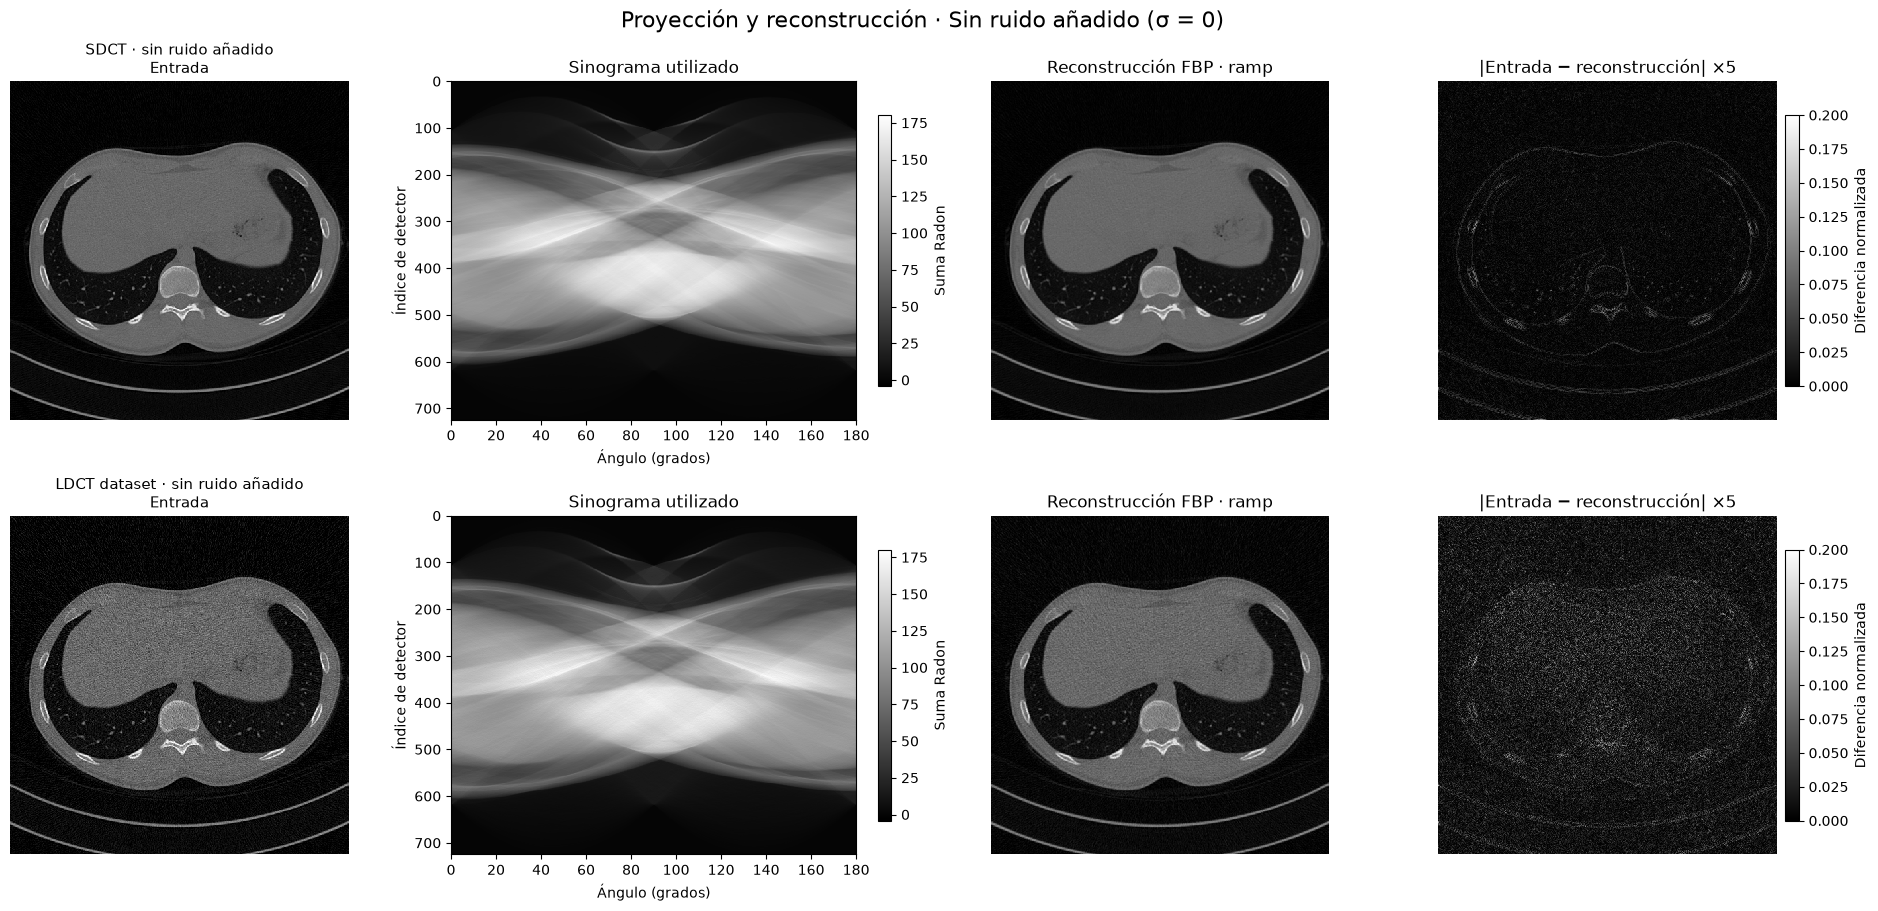

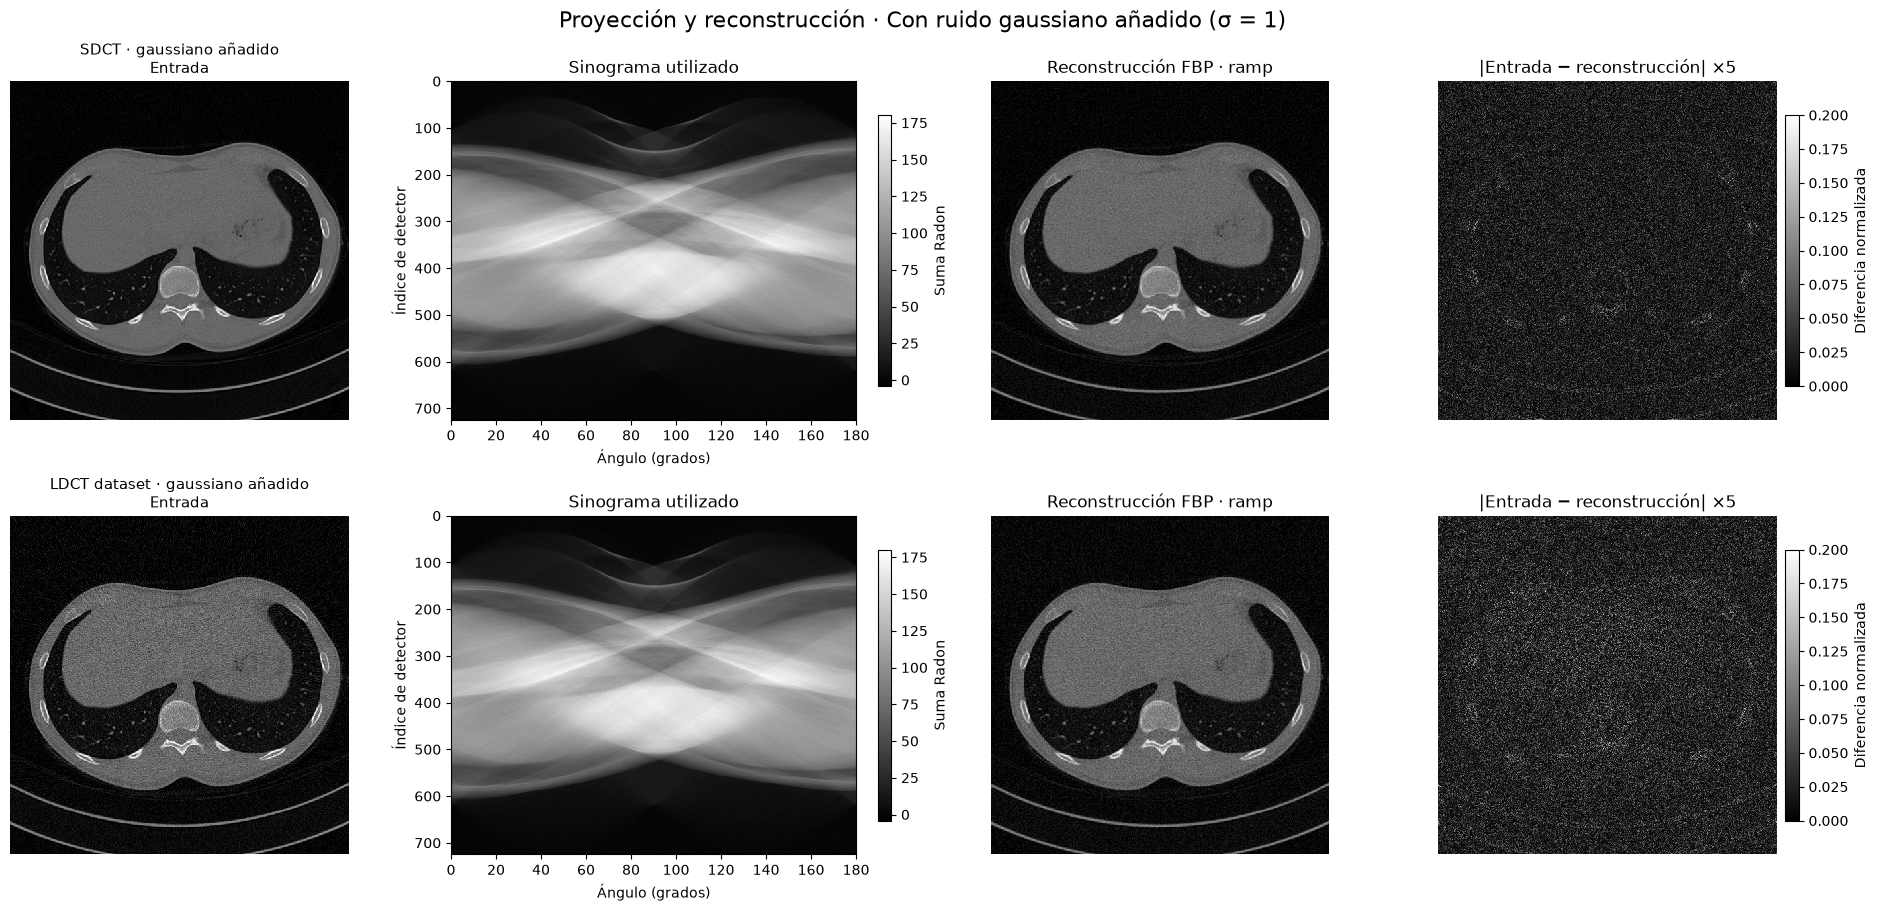

case,MAE_HU,RMSE_HU,MAX_HU
sdct_sin_ruido,22.9248,31.8897,355.433
ldct_sin_ruido,53.3041,68.8989,446.964
sdct_gaussiano,62.676,78.9061,435.844
ldct_gaussiano,79.0119,99.7,612.323


In [2]:
from src.experiments import report_experiment
from src.visualization import plot_report
from src.io import file_hash
from src.normalization import denormalize_image
import importlib.metadata as metadata
import platform
pair, cases = report_experiment(config)
rows = [dict(case=c['case'], MAE_HU=c['MAE_HU'], RMSE_HU=c['RMSE_HU'], MAX_HU=c['MAX_HU']) for c in cases]
figures = plot_report(cases, config['sigma_gaussian'], config['visual_amplification'])
for fig, name in zip(figures, ('09_report_without_added_noise.png', '09_report_with_added_noise.png')):
    finish_figure(fig, output_path('figures', name))
show_table(rows)
save_table(rows, output_path('tables', '09_report_metrics.csv'))

Todas las métricas usan el corte completo, incluido fondo y camilla. La referencia LDCT es LDCT, no SDCT. El ×5 cambia solo la ventana gráfica. MAE = media(|e|), RMSE = √media(e²), máximo = max(|e|).

In [3]:
VERIFY_PUBLISHED_REFERENCE = False  # Actívalo solo para C095/1-250 y parámetros originales.
if VERIFY_PUBLISHED_REFERENCE:
    from validate import verify_published_metrics
    assert verify_published_metrics(rows) == 12
np.savez_compressed(output_path('reconstructed_images', '09_report.npz'),
                    **{c['case']: denormalize_image(c['reconstruction'], pair['scale']) for c in cases},
                    theta=pair['theta'])
save_json(dict(parameters={k: v for k, v in config.items() if k not in ('sdct', 'ldct')},
               normalization_hu=[pair['scale'].minimum, pair['scale'].maximum],
               image_shape=list(pair['sdct'].shape), sinogram_shape=list(cases[0]['sinogram'].shape),
               input_sha256={k: file_hash(config[k]) for k in ('sdct', 'ldct')},
               versions={p: metadata.version(p) for p in ('numpy', 'scipy', 'scikit-image', 'pydicom', 'matplotlib')},
               python=platform.python_version(), circle=False, interpolation='linear'),
          output_path('tables', '09_execution.json'))

Los notebooks 06–08 reproducen los resultados ampliados del Hito 1. Sus CSV y figuras se exportan independientemente: este notebook no necesita que se hayan ejecutado para reconstruir las cifras de la versión anterior. Ejecuta `python reproduce.py` y `python validate.py --reference --originals` para validar todo el recorrido.

## Observaciones

Los doce valores publicados constituyen una referencia verificable de la versión anterior. La ampliación incluye cinco filtros y DFT/FFT por confirmación del usuario y por los resultados/presentación existentes. Un único corte y semilla no permite generalizar el efecto del filtro, ni atribuir diferencias mínimas DFT/FFT a transformaciones matemáticas distintas.